# Chapter 07 답안 양식. 그래프로 데이터의 이야기를 보여주기

> 이 내용을 `chapter07.ipynb`의 Markdown 셀로 작성합니다.

## 제출 정보
- 이름: 이상재
- GitHub ID: sangjae-lee97
- 작성일: 2026.09.18
- 최종 Notebook URL: https://github.com/sangjae-lee97/kant-axagent-study/blob/main/llm-data-analysis-course/chapter07/chapter07.ipynb

## 1. 시각화 질문과 그래프 선택
| 질문 | 선택한 그래프 | 선택 이유 |
| --- | --- | --- |
| 카테고리별 completed 주문 금액 비교 | 막대그래프 | 변화가 중요한게 아닌 비교가 중요하고 대상 항목이 많지 않기에 가능 |
| 월별 completed 주문 금액 변화 | 선그래프 | 같은 대상의 시간에 따른 흐름 변화를 보고 싶기 대문에 선 그래프가 적합 |
| 상품 가격 분포 | 히스토그램/분포 그래프 | 주문한 상품이 어느 가격대에 몰려있는지 파악하기 위해서 |

In [48]:
# 경로 설정
from course_utils.paths import get_project_root, get_data_dir
import pandas as pd
import numpy as np

print("프로젝트 루트 :", get_project_root())
print("데이터 폴더 :", get_data_dir())

RAW_DIR = get_project_root() / "data" / "raw"
PROCESSED_DIR = get_project_root() / "data" / "processed"
REPORT_DIR = get_project_root() / "reports"
PROJECT_ROOT = get_project_root()

프로젝트 루트 : C:\dev\kant-axagent-study\llm-data-analysis-course
데이터 폴더 : C:\dev\kant-axagent-study\llm-data-analysis-course\data


In [49]:
# processed 데이터 불러오기
customers = pd.read_csv(PROCESSED_DIR/"customers_clean.csv")
orders = pd.read_csv(PROCESSED_DIR/"orders_clean.csv")
order_items = pd.read_csv(PROCESSED_DIR/"order_items_clean.csv")
products = pd.read_csv(PROCESSED_DIR/"products_clean.csv")

In [50]:
# clean 데이터에 line_total, order_status, order_month 확인
print(order_items.head())
print(orders.head())

   order_item_id  order_id  product_id  quantity  unit_price  line_total
0              1         1         100         3      102000      306000
1              2         1          87         5       25000      125000
2              3         1           7         3      142000      426000
3              4         1           9         3      193000      579000
4              5         2          72         4      189000      756000
   order_id  customer_id  order_date payment_method order_status order_month  \
0         1          123  2026-05-07           card    completed     2026-05   
1         2           77  2025-07-23      naver_pay    cancelled     2025-07   
2         3          138  2025-11-19  bank_transfer    cancelled     2025-11   
3         4           57  2026-01-30      kakao_pay    cancelled     2026-01   
4         5          125  2025-12-21           card    cancelled     2025-12   

  order_dayofweek  
0        Thursday  
1       Wednesday  
2       Wednesday  
3

In [51]:
# order_items와 병합
order_items_with_status = order_items.merge(
    orders[["order_id","order_status","order_month"]],
    on= "order_id",
    how = "left",
    validate = "many_to_one",
)
order_items_with_status.head()

,order_item_id,order_id,product_id,quantity,unit_price,line_total,order_status,order_month
0,1,1,100,3,102000,306000,completed,2026-05
1,2,1,87,5,25000,125000,completed,2026-05
2,3,1,7,3,142000,426000,completed,2026-05
3,4,1,9,3,193000,579000,completed,2026-05
4,5,2,72,4,189000,756000,cancelled,2025-07


In [52]:
# product와 병합
order_items_with_status_category = order_items_with_status.merge(
    products[["product_id", "category"]],
    on="product_id",
    how = "left",
    validate = "many_to_one",
)
order_items_with_status_category.head()

,order_item_id,order_id,product_id,quantity,unit_price,line_total,order_status,order_month,category
0,1,1,100,3,102000,306000,completed,2026-05,도서
1,2,1,87,5,25000,125000,completed,2026-05,도서
2,3,1,7,3,142000,426000,completed,2026-05,도서
3,4,1,9,3,193000,579000,completed,2026-05,스포츠
4,5,2,72,4,189000,756000,cancelled,2025-07,뷰티


In [53]:
# completed 주문만 추리기
completed_orders = order_items_with_status_category[order_items_with_status["order_status"] == "completed"]

completed_orders.head()

,order_item_id,order_id,product_id,quantity,unit_price,line_total,order_status,order_month,category
0,1,1,100,3,102000,306000,completed,2026-05,도서
1,2,1,87,5,25000,125000,completed,2026-05,도서
2,3,1,7,3,142000,426000,completed,2026-05,도서
3,4,1,9,3,193000,579000,completed,2026-05,스포츠
12,13,6,83,3,24000,72000,completed,2026-03,전자기기


In [54]:
# category별 그룹화
category_sales = (
    completed_orders
    .groupby("category", as_index=False)
    .agg(
        total_quantity = ("quantity","sum"),
        total_sales = ("line_total", "sum")
    ).sort_values("total_sales",ascending=False)
)

category_sales.head()

,category,total_quantity,total_sales
3,스포츠,295,31743000
5,전자기기,259,26400000
2,생활용품,272,23915000
1,뷰티,223,23383000
4,식품,133,16573000


In [63]:
# 월별 그룹화
monthly_sales = (
    completed_orders
    .groupby("order_month",as_index=False)
    .agg(
        total_sales = ("line_total","sum"),
        total_quantity = ("quantity", "sum")
    ).sort_values("order_month")
)

monthly_sales

,order_month,total_sales,total_quantity
0,2025-07,5869000,52
1,2025-08,15621000,127
2,2025-09,10190000,102
3,2025-10,25766000,248
4,2025-11,8812000,93
5,2025-12,11501000,111
6,2026-01,17423000,158
7,2026-02,9749000,100
8,2026-03,13429000,130
9,2026-04,17553000,181


In [56]:
# 가격별 분포 확인
price_quantity = (
    completed_orders
    .groupby("unit_price", as_index=False)
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("line_total", "sum")
    )
    .sort_values("unit_price")
)

price_quantity

,unit_price,total_quantity,total_sales
0,5000,34,170000
1,10000,13,130000
2,11000,21,231000
3,20000,6,120000
4,23000,20,460000
...,...,...,...
74,193000,30,5790000
75,196000,9,1764000
76,197000,19,3743000
77,198000,3,594000


In [57]:
# 한글과 마이너스 폰트 바꾸기
from matplotlib import font_manager
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ["Malgun Gothic", "AppleGothic", "Apple SD Gothic Neo", "Noto Sans CJK KR", "NanumGothic"]

import matplotlib.pyplot as plt

korean_font = next(
    (name for name in font_candidates if name in installed_fonts), None
)

print("선택된 한글 폰트: ", korean_font)

if korean_font:
    plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

선택된 한글 폰트:  Malgun Gothic


## 2. 대표 그래프 1
![카테고리별 비교](images/graph01.png)

### 원본 집계값

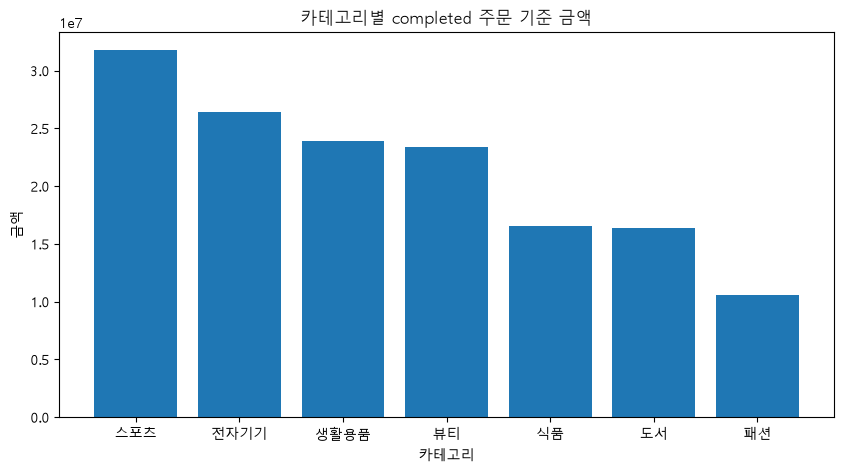

In [60]:
# 카테고리별 그래프
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    category_sales["category"],
    category_sales["total_sales"],
)
ax.set_title("카테고리별 completed 주문 기준 금액")
ax.set_xlabel("카테고리")
ax.set_ylabel("금액")
ax.set_ylim(bottom=0)
fig.savefig(
    "graph02.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


### 결과 관찰

카테고리별 completed 주문 금액에는 차이가 나타났다.

가장 높은 주문 금액을 기록한 카테고리는 **스포츠**였고, 가장 낮은 카테고리는 **패션**이었다.

또한 막대의 길이를 비교하면 스포츠와 전자기기 카테고리가 다른 카테고리보다 상대적으로 높은 주문 금액을 기록한 것을 확인할 수 있다.

### 나의 해석과 판단

카테고리마다 completed 주문에서 발생한 금액 규모가 동일하지 않다는 것을 확인할 수 있다.

다만 주문 금액이 높다는 사실만으로 해당 카테고리의 상품이 더 많이 판매되었다고 판단할 수는 없다. 상품의 단가가 높아서 총 주문 금액이 커졌을 가능성도 있기 때문이다.

따라서 정확한 비교를 위해서는 카테고리별 주문 수량과 상품 단가도 함께 확인할 필요가 있다.

### 업무·분석적 의미

카테고리별 주문 금액을 비교하면 어느 카테고리가 전체 매출에서 상대적으로 큰 비중을 차지하는지 확인할 수 있다.

이를 바탕으로 주요 매출 카테고리를 파악하고, 이후 카테고리별 판매 수량이나 상품 가격을 추가 분석할 대상을 선정할 수 있다.

### 한계와 추가 확인 사항

이번 그래프는 `order_status == "completed"`인 주문의 금액만 비교한 결과이다.

그래프만으로는 카테고리별 금액 차이가 **판매 수량 때문인지, 상품 가격 때문인지** 알 수 없다.

또한 카테고리별 상품 수가 다를 수 있으므로 단순 총금액만으로 카테고리의 성과를 판단하기에는 한계가 있다.

추가로 다음 항목을 확인할 필요가 있다.

- 카테고리별 completed 주문 수량
- 카테고리별 상품 수
- 카테고리별 평균 상품 단가
- 카테고리별 주문 건수

## 3. 대표 그래프 2
![월별 비교](./images/graph02.png)

### 원본 집계값

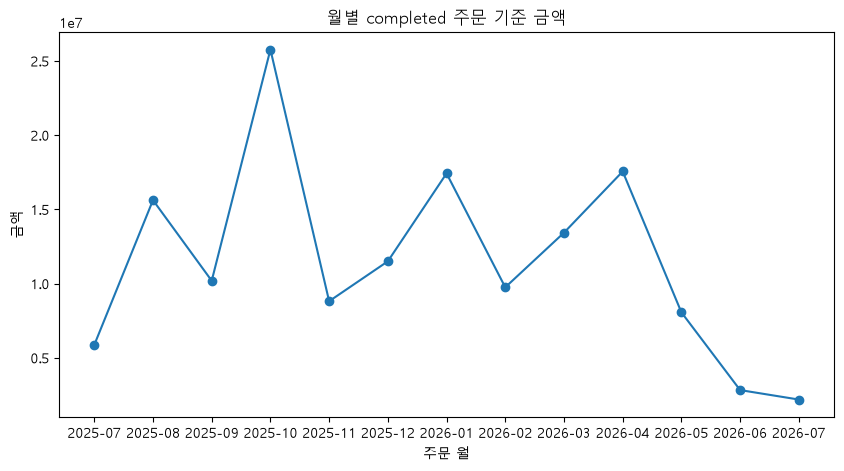

In [64]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    monthly_sales["order_month"],
    monthly_sales["total_sales"],
    marker="o",
)
ax.set_title("월별 completed 주문 기준 금액")
ax.set_xlabel("주문 월")
ax.set_ylabel("금액")
fig.savefig(
    "graph01.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### 결과 관찰

월별 completed 주문 금액은 일정하게 증가하거나 감소하지 않고 월마다 변동하는 모습을 보였다.

가장 높은 주문 금액은 **2025년 10월**에 나타났고, 약 2,600만 원 수준이었다.

2025년 7월부터 10월까지는 전체적으로 증가하는 흐름이 나타났지만, 2025년 11월에는 주문 금액이 크게 감소했다.

이후 다시 증가와 감소를 반복했으며, 2026년 4월 이후에는 주문 금액이 계속 감소하여 2026년 7월에는 가장 낮은 수준을 기록했다.

### 나의 해석과 판단

월별 completed 주문 금액은 일정한 방향으로 움직이기보다 상승과 하락을 반복하고 있다.

특히 2025년 10월의 높은 금액과 2026년 6~7월의 낮은 금액이 눈에 띈다.

다만 이 그래프만으로 특정 월의 주문 금액이 증가하거나 감소한 원인을 판단할 수는 없다.

주문 건수의 변화, 주문 수량, 상품 단가, 특정 카테고리의 판매 증가 등 여러 요인이 영향을 주었을 가능성이 있다.

### 업무·분석적 의미

월별 주문 금액 변화를 확인하면 매출이 상대적으로 높았던 시기와 낮았던 시기를 파악할 수 있다.

특히 주문 금액이 크게 증가하거나 감소한 월을 선정하여 해당 기간의 주문 건수, 상품 수량, 카테고리별 판매 금액 등을 추가로 분석할 수 있다.

이를 통해 단순한 월별 변화 확인을 넘어 어떤 요인이 월별 주문 금액 변화와 함께 나타났는지 확인할 수 있다.

### 한계와 추가 확인 사항

이번 그래프는 `order_status == "completed"`인 주문의 월별 `line_total` 합계만 나타낸 결과이다.

따라서 그래프만으로 월별 주문 금액 변화의 원인을 설명할 수 없다.

또한 마지막 기간인 2026년 6월과 7월의 값이 낮은 것이 실제 매출 감소 때문인지, 해당 월의 데이터가 충분히 수집되지 않은 것인지도 확인이 필요하다.

추가로 다음 항목을 확인할 필요가 있다.

- 월별 completed 주문 건수
- 월별 completed 주문 수량
- 월별 평균 주문 금액
- 월별 카테고리별 주문 금액
- 각 월의 데이터 수집 기간이 동일한지 여부

## 4. 대표 그래프 3
![가격별 판매량 3](./images/graph03.png)

### 원본 집계값

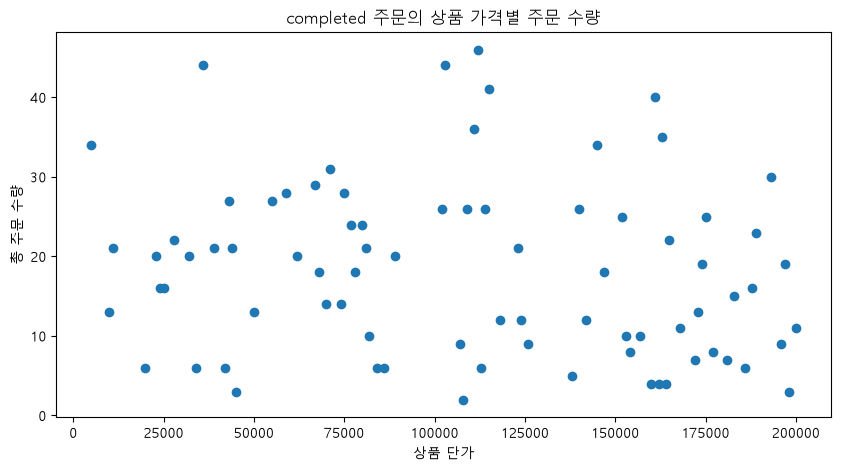

In [68]:
plt.figure(figsize=(10, 5))

plt.scatter(
    price_quantity["unit_price"],
    price_quantity["total_quantity"]
)

plt.xlabel("상품 단가")
plt.ylabel("총 주문 수량")
plt.title("completed 주문의 상품 가격별 주문 수량")

fig.savefig(
    "graph03.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### 결과 관찰

상품 단가와 총 주문 수량을 산점도로 확인한 결과, 점들이 전체 구간에 넓게 퍼져 있었다.

낮은 가격대에서도 주문 수량이 많은 상품과 적은 상품이 모두 나타났고, 높은 가격대에서도 비슷한 모습이 나타났다.

따라서 상품 단가가 높아질수록 주문 수량이 일정하게 증가하거나 감소하는 뚜렷한 패턴은 확인하기 어려웠다.

일부 가격대에서는 주문 수량이 40개 이상인 상품도 있었지만, 같은 가격대 주변에서도 주문 수량 차이가 크게 나타났다.

### 나의 해석과 판단

이번 그래프만 보면 상품 단가와 주문 수량 사이에 강한 관계가 있다고 판단하기 어렵다.

가격이 낮다고 반드시 주문 수량이 많거나, 가격이 높다고 주문 수량이 적은 형태가 나타나지 않았기 때문이다.

따라서 주문 수량에는 가격 외에도 상품 종류, 카테고리, 상품 자체의 인기 등 다른 요인이 영향을 주었을 가능성이 있다고 판단했다.

### 업무·분석적 의미

가격과 주문 수량 사이에 뚜렷한 관계가 보이지 않는다면 가격만을 기준으로 판매량을 설명하기 어렵다는 의미가 있다.

따라서 판매량이 높은 상품을 분석할 때는 상품 가격뿐 아니라 카테고리, 상품별 주문 건수, 평균 주문 수량 등을 함께 확인할 필요가 있다.

또한 특정 가격대에 주문이 집중되는지 확인하려면 산점도보다 가격 구간별 분포를 보여 주는 히스토그램이 더 적절할 수 있다.

### 한계와 추가 확인 사항

이번 산점도는 상품 단가와 총 주문 수량의 관계만 보여 주기 때문에 다른 요인의 영향을 확인할 수 없다.

또한 가격이 비슷한 상품이라도 서로 다른 카테고리와 특성을 가질 수 있으므로 단가만으로 주문 수량 차이를 설명하기에는 한계가 있다.

추가로 다음 항목을 확인할 필요가 있다.

- 가격 구간별 주문 수량 분포
- 카테고리별 상품 단가와 주문 수량
- 상품별 주문 건수
- 가격과 주문 수량의 상관계수

### 내가 발견한 시각화 위험 또는 개선점

카테고리별 막대그래프와 월별 선그래프는 집계표의 값과 비교하여 그래프에 사용된 값이 일치하는지 확인했다.

축 이름과 그래프 제목에는 분석 대상이 `completed` 주문이라는 점과 금액 또는 주문 수량의 의미가 드러나도록 작성했다.

월별 그래프는 `order_month`를 시간 순서대로 정렬하여 실제 시간 흐름과 그래프의 순서가 일치하도록 했다.

다만 금액 그래프의 y축이 `1e7`과 같은 과학적 표기법으로 표시되어 처음 보는 사람이 실제 금액 단위를 바로 이해하기 어려울 수 있다. 따라서 필요하면 원 단위 또는 백만 원 단위로 변경하는 것이 더 이해하기 쉽다.

또한 상품 단가와 주문 수량을 나타낸 산점도에서는 점들이 넓게 퍼져 있어 뚜렷한 관계를 확인하기 어려웠다. 원래 질문이 어느 가격대의 상품이 많이 주문되었는지를 확인하는 것이라면 산점도보다 가격 구간별 히스토그램을 사용하는 것이 더 적절할 수 있다.

그래프의 차이가 실제보다 과장되지 않도록 축 범위를 임의로 잘라 사용하지 않았으며, 그래프만으로 변화의 원인을 단정하지 않도록 주의했다.


## 6. Chapter 07 최종 판단

### 가장 중요한 그래프 1개와 이유

가장 중요한 그래프는 **카테고리별 completed 주문 금액 막대그래프**라고 판단했다.

카테고리별 주문 금액을 한눈에 비교할 수 있고, 어떤 카테고리가 전체 매출에서 상대적으로 큰 금액을 차지하는지 가장 쉽게 확인할 수 있기 때문이다.

또한 이후 주문 수량, 상품 단가, 주문 건수 등을 추가로 분석할 카테고리를 선정하는 기준으로 활용할 수 있다.

### 그래프가 보여 준 사실

카테고리별 completed 주문 금액에는 차이가 있었다.

스포츠 카테고리의 주문 금액이 가장 높았으며 패션 카테고리의 주문 금액이 가장 낮았다.

월별 completed 주문 금액도 일정하게 증가하거나 감소하지 않고 월마다 변동하는 모습을 보였다.

상품 단가와 주문 수량의 산점도에서는 가격이 높아질수록 주문 수량이 일정하게 증가하거나 감소하는 뚜렷한 패턴을 확인하기 어려웠다.

### 그래프만으로 말할 수 없는 것

그래프만으로 카테고리별 주문 금액 차이가 발생한 원인을 알 수는 없다.

주문 금액이 높은 이유가 주문 수량이 많기 때문인지, 상품 단가가 높기 때문인지 추가 분석이 필요하다.

또한 특정 월에 주문 금액이 증가하거나 감소한 원인도 그래프만으로 판단할 수 없다.

상품 단가와 주문 수량 사이에서도 산점도만으로 가격이 주문 수량의 원인이라고 판단할 수 없다.

따라서 그래프는 데이터에서 나타난 패턴을 확인하는 데 사용할 수 있지만, 그 원인까지 직접 설명하는 자료로 사용해서는 안 된다.

### 다음 분석에서 확인할 질문

다음 분석에서는 다음 질문을 추가로 확인할 필요가 있다.

- 카테고리별 주문 금액 차이는 주문 수량과 상품 단가 중 어떤 요인의 영향을 더 많이 받는가?
- 월별 주문 금액이 크게 증가하거나 감소한 시기에는 주문 건수와 주문 수량도 함께 변화했는가?
- 어떤 가격대의 상품이 실제로 가장 많이 주문되었는가?
- 카테고리별로 상품 가격과 주문 수량의 관계가 다르게 나타나는가?
- 주문 금액이 높은 상품 또는 카테고리는 전체 completed 매출에서 어느 정도의 비중을 차지하는가?


## 최종 체크

- [x] 그래프와 수치를 교차 검증했습니다.
- [x] 관찰과 해석을 구분했습니다.
- [x] 업무적 의미와 한계를 작성했습니다.
- [x] 최종 Notebook URL을 제출합니다.